In [16]:
# Import libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Data municipio Carlos Paz**

In [11]:
url_mcp = "https://em.carlospaz.gob.ar/api/archives/1/2023-01-01/2026-01-01"
r_mcp = requests.get(url_mcp, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)

print(r_mcp.status_code)
print(r_mcp.headers.get("content-type"))
data_mcp = r_mcp.json()
'''print(type(data))
print(data[:2] if isinstance(data, list) else list(data.keys()))'''

200
application/json; charset=utf-8


'print(type(data))\nprint(data[:2] if isinstance(data, list) else list(data.keys()))'

In [25]:
# --
df_mcp = pd.json_normalize(data_mcp)

# --
df_mcp['dateTime'] = pd.to_datetime(df_mcp['dateTime'])

# --
df_mcp.sample(5)

,avg_pressure,outTempMax,outTempMin,avg_outHumidity,avg_windSpeed,avg_windDir,total_rain,avg_dewpoint,avg_heatindex,dateTime
392,942,33.0,10.0,33.0,3,200.244604,0.0,2.1,21.7,2024-10-05 03:00:00+00:00
400,946,18.0,14.0,88.0,4,181.572519,0.0,13.4,15.4,2024-10-13 03:00:00+00:00
277,949,12.3,8.8,89.0,3,191.303811,0.1,9.1,10.9,2024-04-11 03:00:00+00:00
642,949,-40.0,-40.0,NaN,5,198.464789,0.0,NaN,NaN,2025-08-24 03:00:00+00:00
755,941,29.0,13.0,57.0,4,177.627907,0.0,9.5,19.9,2025-12-15 03:00:00+00:00


**Data escuela Dante Alighieri**

In [10]:
url_eda = "https://em.carlospaz.gob.ar/api/archives/3/2023-01-01/2026-01-01"
r_eda = requests.get(url_eda, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)

print(r_eda.status_code)
print(r_eda.headers.get("content-type"))
data_eda = r_eda.json()

200
application/json; charset=utf-8


In [26]:
# --
df_eda = pd.json_normalize(data_eda)                  # if it's a list of records

# --
df_eda['dateTime'] = pd.to_datetime(df_eda['dateTime'])

# --
df_eda.sample(5)

,avg_pressure,outTempMax,outTempMin,avg_outHumidity,avg_windSpeed,avg_windDir,total_rain,avg_dewpoint,avg_heatindex,dateTime
608,938,28.0,15.0,45.0,2,138.436508,0.0,9.5,22.4,2024-10-06 03:00:00+00:00
917,938,25.0,10.0,70.0,2,141.065574,0.0,11.4,18.0,2025-12-15 03:00:00+00:00
811,936,15.0,5.0,92.0,2,185.036810,0.0,9.3,10.6,2025-08-31 03:00:00+00:00
349,927,35.9,21.9,72.0,5,271.187589,1.3,22.9,32.3,2023-12-16 03:00:00+00:00
62,937,34.7,15.3,63.0,2,85.432020,0.0,15.7,24.9,2023-03-04 03:00:00+00:00


**Plot test**

In [61]:
max_temp_mcp = np.array(df_mcp['outTempMax'])
max_temp_eda = np.array(df_eda['outTempMax'])

# --
mtm_norm = (max_temp_mcp-max_temp_mcp.min())/(max_temp_mcp.max()-max_temp_mcp.min())
mte_norm = (max_temp_eda-max_temp_eda.min())/(max_temp_eda.max()-max_temp_eda.min())

# --
'''mtm_norm_outl = np.where(((mtm_norm < np.nanpercentile(mtm_norm, 5)) | (mtm_norm > np.nanpercentile(mtm_norm, 98))), np.nan, mtm_norm)
mte_norm_outl = np.where(((mte_norm < np.nanpercentile(mte_norm, 2)) | (mte_norm > np.nanpercentile(mte_norm, 98))), np.nan, mte_norm)'''
mtm_norm_outl = np.where(((mtm_norm < np.nanmedian(mtm_norm)-2*np.nanstd(mtm_norm)) | (mtm_norm > np.nanmedian(mtm_norm)+2*np.nanstd(mtm_norm))), np.nan, mtm_norm)
mte_norm_outl = np.where(((mte_norm < np.nanmedian(mte_norm)-2*np.nanstd(mte_norm)) | (mte_norm > np.nanmedian(mte_norm)+2*np.nanstd(mte_norm))), np.nan, mte_norm)

#mte_norm_outl = np.where(((mte_norm < np.nanpercentile(mte_norm, 2)) | (mte_norm > np.nanpercentile(mte_norm, 98))), np.nan, mte_norm)

In [56]:
np.nanpercentile(mtm_norm, 10)

np.float64(0.0)

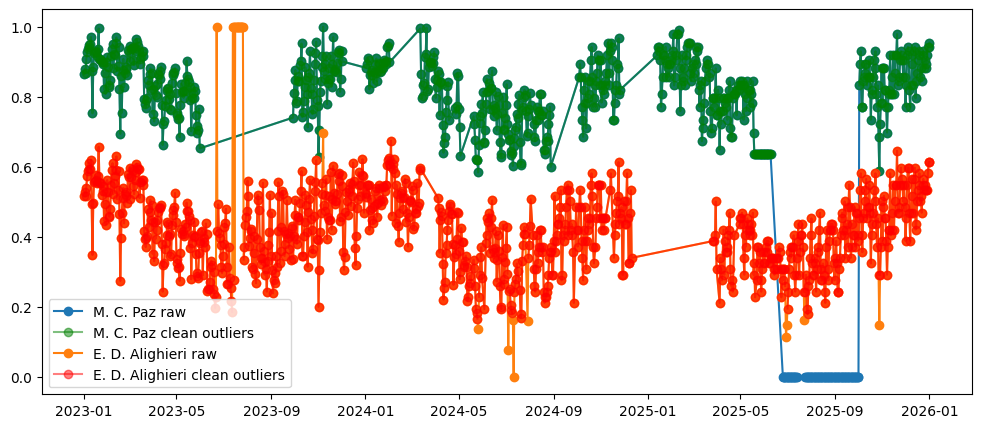

In [65]:
# --
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_mcp['dateTime'], mtm_norm, marker='o', label='M. C. Paz raw')
ax.plot(df_mcp['dateTime'], mtm_norm_outl, color='green', marker='o', alpha=0.5, label='M. C. Paz clean outliers')
ax.plot(df_eda['dateTime'], mte_norm, marker='o', label='E. D. Alighieri raw')
ax.plot(df_eda['dateTime'], mte_norm_outl, color='red', marker='o', alpha=0.5, label='E. D. Alighieri clean outliers')
ax.legend(loc='best')

**Export data**

In [66]:
# --
df_mcp.to_csv('data_meteo_mcp_2326.csv', index=False)
df_eda.to_csv('data_meteo_eda_2326.csv', index=False)